# Visualizing the Coldest Places Dataset

This section explores trends and distributions in the dataset of the coldest places through visualizations.

---

### **1. Histogram of Temperatures**
- A histogram is used to display the distribution of temperatures in the dataset.
- The x-axis represents the temperature in degrees Celsius, while the y-axis shows the frequency of occurrences.
- A KDE (Kernel Density Estimate) curve overlays the histogram to highlight the density of temperatures.
- **Key Insight**: Temperatures are spread out across the dataset, with certain ranges being more frequent.

---

### **2. Latitude vs. Temperature Scatter Plot**
- A scatter plot is created to explore the relationship between latitude and temperature.
- Each point represents a place, with its latitude plotted on the x-axis and its temperature on the y-axis.
- A red trendline is added to summarize the overall trend in the data.
- **Key Insight**: As latitude increases (moving further from the equator), temperatures tend to decrease, showing an inverse relationship.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.tools as tls
import plotly.io as pio
import plotly.express as px

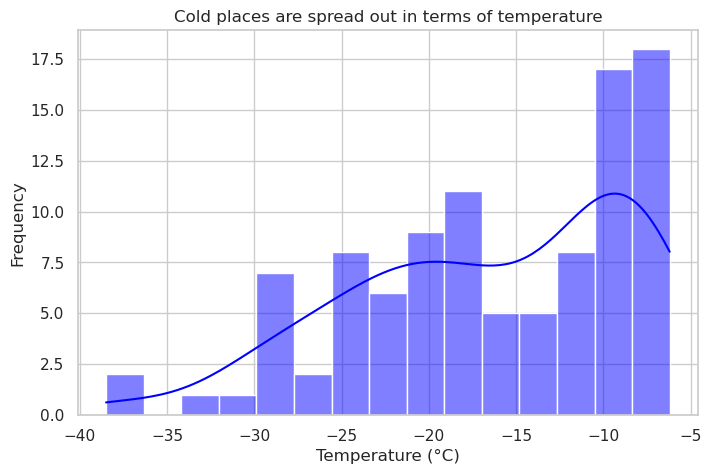

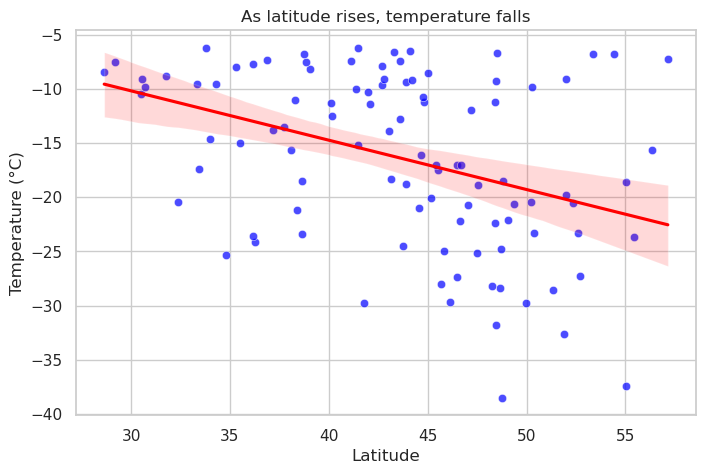

In [4]:
# Load the dataset
file_path = "../../data/weather_data/coldest_places.csv"  
df_coldest = pd.read_csv(file_path)

# Set visualization style
sns.set(style="whitegrid")

# 1. Histogram of Temperatures
plt.figure(figsize=(8, 5))
sns.histplot(df_coldest["temperature"], bins=15, kde=True, color="blue")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Cold places are spread out in terms of temperature")
plt.show()


# 2. Latitude vs. Temperature Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_coldest["latitude"], y=df_coldest["temperature"], color="blue", alpha=0.7)
sns.regplot(x=df_coldest["latitude"], y=df_coldest["temperature"], scatter=False, color="red")  # Generate trendline that summarises trend of many scattered points

plt.xlabel("Latitude")
plt.ylabel("Temperature (°C)")
plt.title("As latitude rises, temperature falls")
plt.grid(True)
plt.show()



# Further analysis of hottest and coldest top 100 places

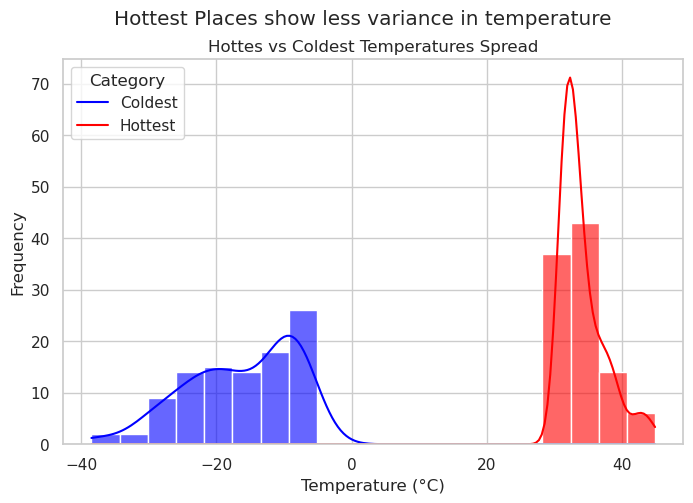

In [19]:
file_path = "../../data/weather_data/hottest_places.csv" 
df_hottest = pd.read_csv(file_path)

# Add category labels
df_hottest["category"] = "hottest"
df_coldest["category"] = "coldest"

# Combine both datasets
df_combined = pd.concat([df_hottest, df_coldest], ignore_index=True)

# Histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df_combined, x="temperature", hue="category", bins=20, kde=True, 
             palette={"hottest": "red", "coldest": "blue"}, alpha=0.6)

plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.suptitle("Hottest Places show less variance in temperature")
plt.title("Hottes vs Coldest Temperatures Spread")
plt.legend(title="Category", labels=["Coldest", "Hottest"])
plt.grid(True)
#to save the graph
plt.savefig("../../visuals/images/hotvscold_spread_plot.png", format='png')
plt.show()


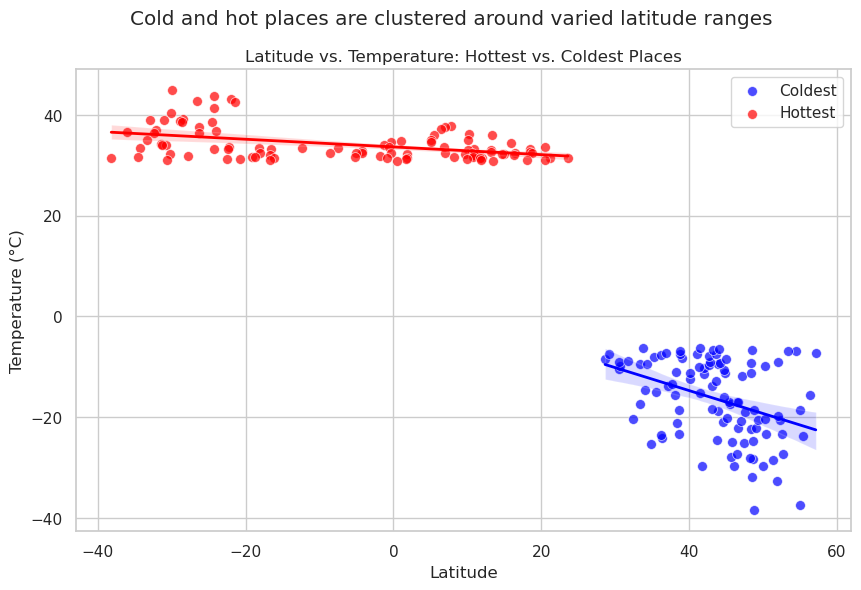

In [20]:
plt.figure(figsize=(10, 6))

# Scatter plot for both hottest and coldest places
sns.scatterplot(data=df_coldest, x="latitude", y="temperature", color="blue", label="Coldest", s=50, alpha=0.7)
sns.scatterplot(data=df_hottest, x="latitude", y="temperature", color="red", label="Hottest", s=50, alpha=0.7)

# Trendlines for hottest and coldest places
sns.regplot(data=df_hottest, x="latitude", y="temperature", scatter=False, color="red", line_kws={"linewidth": 2})
sns.regplot(data=df_coldest, x="latitude", y="temperature", scatter=False, color="blue", line_kws={"linewidth": 2})

plt.xlabel("Latitude")
plt.ylabel("Temperature (°C)")
plt.suptitle("Cold and hot places are clustered around varied latitude ranges")
plt.title("Latitude vs. Temperature: Hottest vs. Coldest Places")
plt.legend()
plt.grid(True)
#to save the graph
plt.savefig("../../visuals/images/lat_temp.png", format='png')
plt.show()



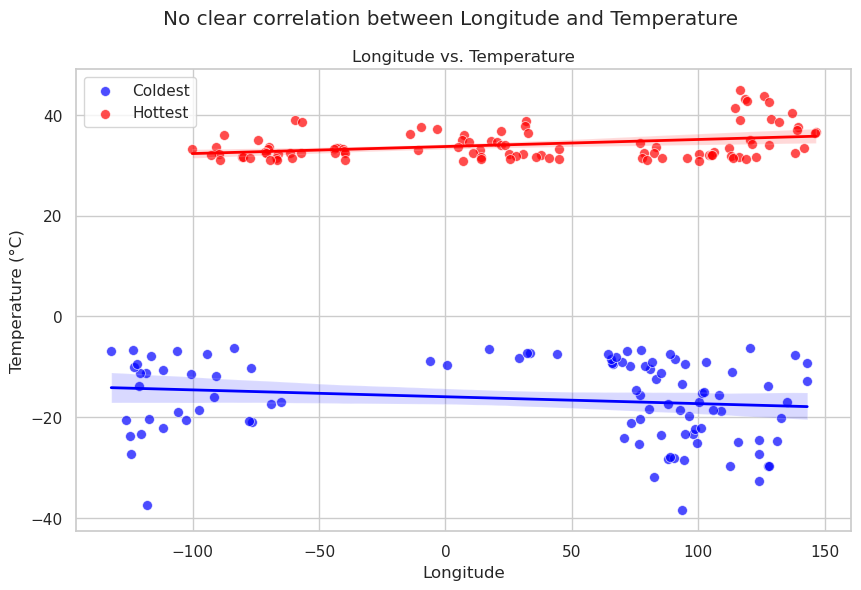

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_coldest, x="longitude", y="temperature", color="blue", label="Coldest", s=50, alpha=0.7)
sns.scatterplot(data=df_hottest, x="longitude", y="temperature", color="red", label="Hottest", s=50, alpha=0.7)

sns.regplot(data=df_hottest, x="longitude", y="temperature", scatter=False, color="red", line_kws={"linewidth": 2})
sns.regplot(data=df_coldest, x="longitude", y="temperature", scatter=False, color="blue", line_kws={"linewidth": 2})

plt.xlabel("Longitude")
plt.ylabel("Temperature (°C)")
plt.suptitle("No clear correlation between Longitude and Temperature")
plt.title("Longitude vs. Temperature")
plt.legend()
plt.grid(True)
plt.savefig("../../visuals/images/long_temp.png", format='png')
plt.show()


### Simple Explanation

I used **regression** to see how location (latitude and longitude) affects temperature. Here's what I found:

- **Latitude (how far north or south a place is)** has a strong effect on temperature. This makes sense because we know that places closer to the equator are usually hotter, and places closer to the poles are colder. The R Squared value for latitude was **0.77**, meaning 77% of the variation in temperature can be explained by how far north or south the place is.

- **Longitude (how far east or west a place is)** doesn’t seem to affect temperature at all. The R Squared value was **0**, meaning it doesn’t explain any variation in temperature. 

In short, temperature depends on **latitude**, not **longitude**!

In [23]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [ ]:
# Assuming your DataFrame is named df and has columns 'latitude' and 'temperature'
X = df_combined['latitude']  # Independent variable (latitude)
y = df_combined['temperature']  # Dependent variable (temperature)

# Add constant for intercept in the model
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            temperature   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     704.5
Date:                Tue, 04 Feb 2025   Prob (F-statistic):           3.85e-67
Time:                        17:39:40   Log-Likelihood:                -786.68
No. Observations:                 200   AIC:                             1577.
Df Residuals:                     198   BIC:                             1584.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.5704      1.019     23.129      0.0

In [25]:
# Initialize the scaler
scaler = StandardScaler()

# Normalize latitude and temperature
df_combined['latitude_norm'] = scaler.fit_transform(df_combined[['latitude']])
df_combined['temperature_norm'] = scaler.fit_transform(df_combined[['temperature']])

# Use the normalized variables for regression
X = df_combined['latitude_norm']  # Independent variable (latitude)
y = df_combined['temperature_norm']  # Dependent variable (temperature)

# Add constant for intercept in the model
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the results
print(model.summary())
with open("../../visuals/html_files/lat_regression.html", "w") as f:
    f.write(model.summary().as_html())


                            OLS Regression Results                            
Dep. Variable:       temperature_norm   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     693.6
Date:                Sun, 09 Feb 2025   Prob (F-statistic):           1.29e-66
Time:                        12:29:12   Log-Likelihood:                -133.31
No. Observations:                 200   AIC:                             270.6
Df Residuals:                     198   BIC:                             277.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.271e-16      0.033  -3.79e-15

In [26]:
scaler = StandardScaler()

# Normalize longitude and temperature
df_combined['longitude_norm'] = scaler.fit_transform(df_combined[['longitude']])
df_combined['temperature_norm'] = scaler.fit_transform(df_combined[['temperature']])

# Use the normalized variables for regression
X = df_combined['longitude_norm']  # Independent variable (latitude)
y = df_combined['temperature_norm']  # Dependent variable (temperature)

# Add constant for intercept in the model
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the results
print(model.summary())
with open("../../visuals/html_files/long_regression.html", "w") as f:
    f.write(model.summary().as_html())

                            OLS Regression Results                            
Dep. Variable:       temperature_norm   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.04253
Date:                Sun, 09 Feb 2025   Prob (F-statistic):              0.837
Time:                        12:31:52   Log-Likelihood:                -283.77
No. Observations:                 200   AIC:                             571.5
Df Residuals:                     198   BIC:                             578.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1.271e-16      0.071  -1.79e